<h1><font color='blue'>Análise de Sentimentos e Sistemas de Recomendação</font></h1>
<h2><b>Prática U1-T3-V1.2-Avaliação de modelos de análise de sentimento</b></h2>


---

## Preparação

### Carregando o dataset

In [1]:
import pandas as pd
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1M7VtNfEh7K3gqa4OiWiayPkg8q6x8fXk', encoding='utf-8', low_memory=False)
df.head()

,frase_pt,frase_en,sentimento
0,O atendimento ao cliente foi excepcional e res...,The customer service was exceptional and solve...,Positivo
1,"Este é, sem dúvida, o melhor café que já prove...","This is, without a doubt, the best coffee I've...",Positivo
2,O filme tem uma fotografia incrível e uma tril...,The movie has incredible cinematography and a ...,Positivo
3,Estou muito satisfeito com a qualidade do prod...,I am very satisfied with the product's quality...,Positivo
4,A equipe foi extremamente simpática e prestati...,The staff was extremely friendly and helpful t...,Positivo


In [2]:
df['sentimento'].value_counts()

,count
sentimento,
Positivo,10
Negativo,10
Neutro,10


## Avaliação das abordagens de Análise de Sentimento

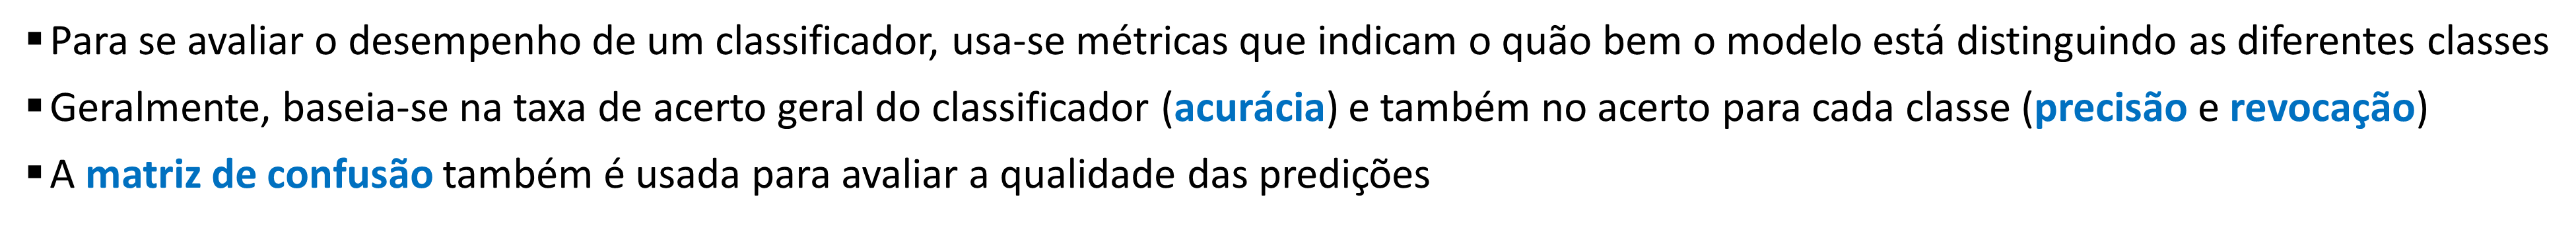

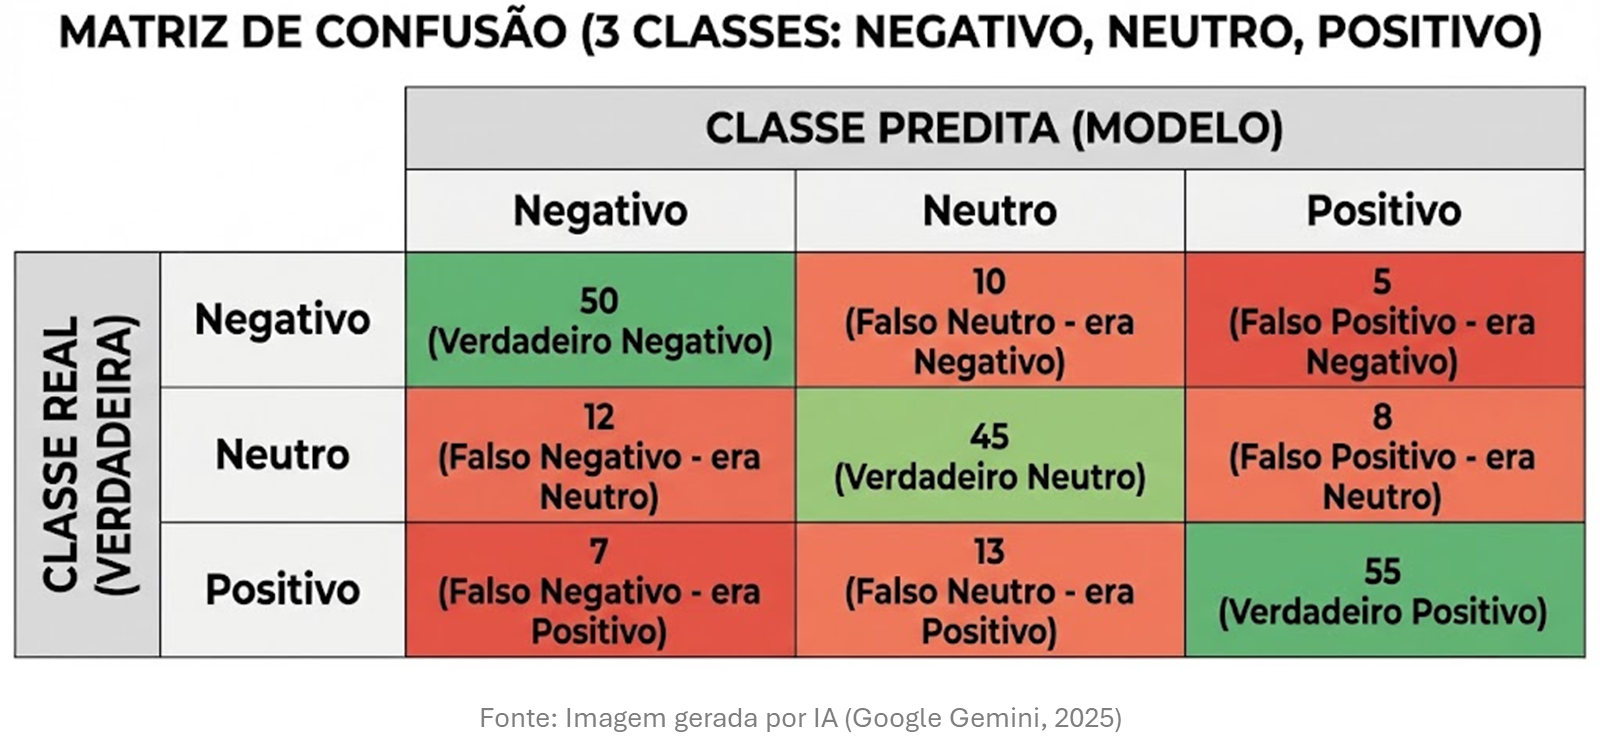

### Frases em inglês

In [3]:
!pip install -q transformers

In [4]:
from transformers import pipeline

#sa = pipeline("sentiment-analysis")
sa = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [5]:
retorno = sa("I like this product")
retorno

[{'label': 'positive', 'score': 0.9538777470588684}]

In [6]:
def retorna_sentimento(retorno):
    if retorno['label'] == 'negative':
        return 'Negativo'
    elif retorno['label'] == 'neutral':
        return 'Neutro'
    elif retorno['label'] == 'positive':
        return 'Positivo'

retorna_sentimento(retorno[0])

'Positivo'

In [7]:
y_pred = []
for frase, sentimento in df[['frase_en','sentimento']].values.tolist():
    res = sa(frase)
    retorno = retorna_sentimento(res[0])
    y_pred.append(retorno)
    print(f'Frase: {frase:<90} - Sentimento: pred "{retorno}" - real "{sentimento}" \n\t{res[0]}')


Frase: The customer service was exceptional and solved my problem quickly.                        - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'positive', 'score': 0.9297541975975037}
Frase: This is, without a doubt, the best coffee I've ever tasted in the city!                    - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'positive', 'score': 0.9859880805015564}
Frase: The movie has incredible cinematography and a moving soundtrack.                           - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'positive', 'score': 0.983791708946228}
Frase: I am very satisfied with the product's quality, it exceeded my expectations.               - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'positive', 'score': 0.9851306080818176}
Frase: The staff was extremely friendly and helpful throughout my entire visit.                   - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'positive', 'score': 0.9793727993965149}
Frase:

Ver a taxa de acerto (acurácia)

In [8]:
from sklearn.metrics import accuracy_score

y_test = df['sentimento'].values.tolist()
accuracy_score(y_test, y_pred)

0.9333333333333333

#### Avaliação das classificações

##### O relatório de classificação

In [9]:
from sklearn.metrics import classification_report

target_names = ['Negativo', 'Neutro', 'Positivo']
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

    Negativo       1.00      0.90      0.95        10
      Neutro       1.00      0.90      0.95        10
    Positivo       0.83      1.00      0.91        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



##### A matriz de confusão

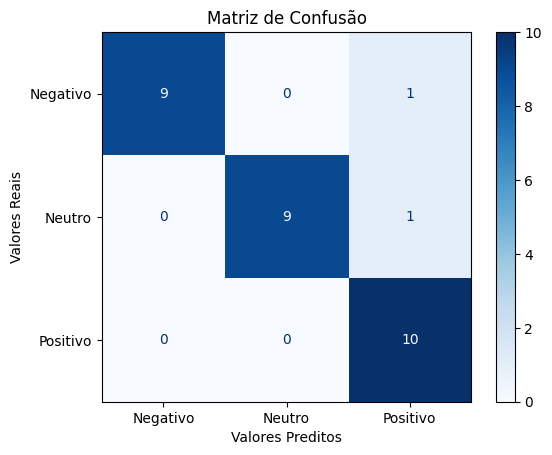

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Gera a matriz de confusão
cm = confusion_matrix(y_test, y_pred, labels=target_names)
# Plota a matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão')
plt.xlabel('Valores Preditos')
plt.ylabel('Valores Reais')
plt.show()

### Frases em português

In [11]:
sa = pipeline("sentiment-analysis",model="lucas-leme/FinBERT-PT-BR")


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: lucas-leme/FinBERT-PT-BR
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/559 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [12]:
retorno = sa("Eu adorei este produto")
retorno

[{'label': 'POSITIVE', 'score': 0.5155050754547119}]

In [13]:
def retorna_sentimento(retorno):
    if retorno['label'] == 'NEGATIVE':
        return 'Negativo'
    elif retorno['label'] == 'NEUTRAL':
        return 'Neutro'
    elif retorno['label'] == 'POSITIVE':
        return 'Positivo'

retorna_sentimento(retorno[0])

'Positivo'

In [14]:
y_pred = []
for frase, sentimento in df[['frase_pt','sentimento']].values.tolist():
    res = sa(frase)
    retorno = retorna_sentimento(res[0])
    y_pred.append(retorno)
    print(f'Frase: {frase:<90} - Sentimento: pred "{retorno}" - real "{sentimento}" \n\t{res[0]}')


Frase: O atendimento ao cliente foi excepcional e resolveu meu problema rapidamente.              - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'POSITIVE', 'score': 0.6414068937301636}
Frase: Este é, sem dúvida, o melhor café que já provei na cidade!                                 - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'POSITIVE', 'score': 0.7515318989753723}
Frase: O filme tem uma fotografia incrível e uma trilha sonora emocionante.                       - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'POSITIVE', 'score': 0.6125232577323914}
Frase: Estou muito satisfeito com a qualidade do produto, superou minhas expectativas.            - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'POSITIVE', 'score': 0.8268324732780457}
Frase: A equipe foi extremamente simpática e prestativa durante toda a minha visita.              - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'POSITIVE', 'score': 0.7414060831069946}
Frase

In [15]:
from sklearn.metrics import accuracy_score

y_test = df['sentimento'].values.tolist()
accuracy_score(y_test, y_pred)

0.8666666666666667

#### Avaliação das classificações

##### O relatório de classificação

In [16]:
from sklearn.metrics import classification_report

target_names = ['Negativo', 'Neutro', 'Positivo']
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

    Negativo       1.00      1.00      1.00        10
      Neutro       0.88      0.70      0.78        10
    Positivo       0.75      0.90      0.82        10

    accuracy                           0.87        30
   macro avg       0.88      0.87      0.87        30
weighted avg       0.88      0.87      0.87        30



##### A matriz de confusão

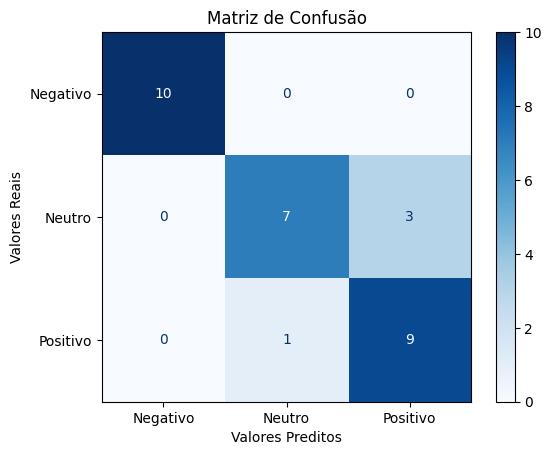

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Gera a matriz de confusão
cm = confusion_matrix(y_test, y_pred, labels=target_names)
# Plota a matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão')
plt.xlabel('Valores Preditos')
plt.ylabel('Valores Reais')
plt.show()